In [1]:
library(tidyverse)
library(forecast)

#-----------------
options(
    repr.plot.width = 14,
    repr.plot.height = 9
)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.1     v readr     2.2.0
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.3     v tibble    3.3.1
v lubridate 1.9.5     v tidyr     1.3.2
v purrr     1.2.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Load Denmark Stock Market PE Ratio based on the iShares MSCI Denmark ETF (EDEN) which serves as the benchmark for the Denmark market. Data are download from [trendonify.com](https://trendonify.com/denmark/stock-market/pe-ratio?utm_source=chatgpt.com).

In [ ]:
pe <- read.csv("data/pe_ratios.csv")

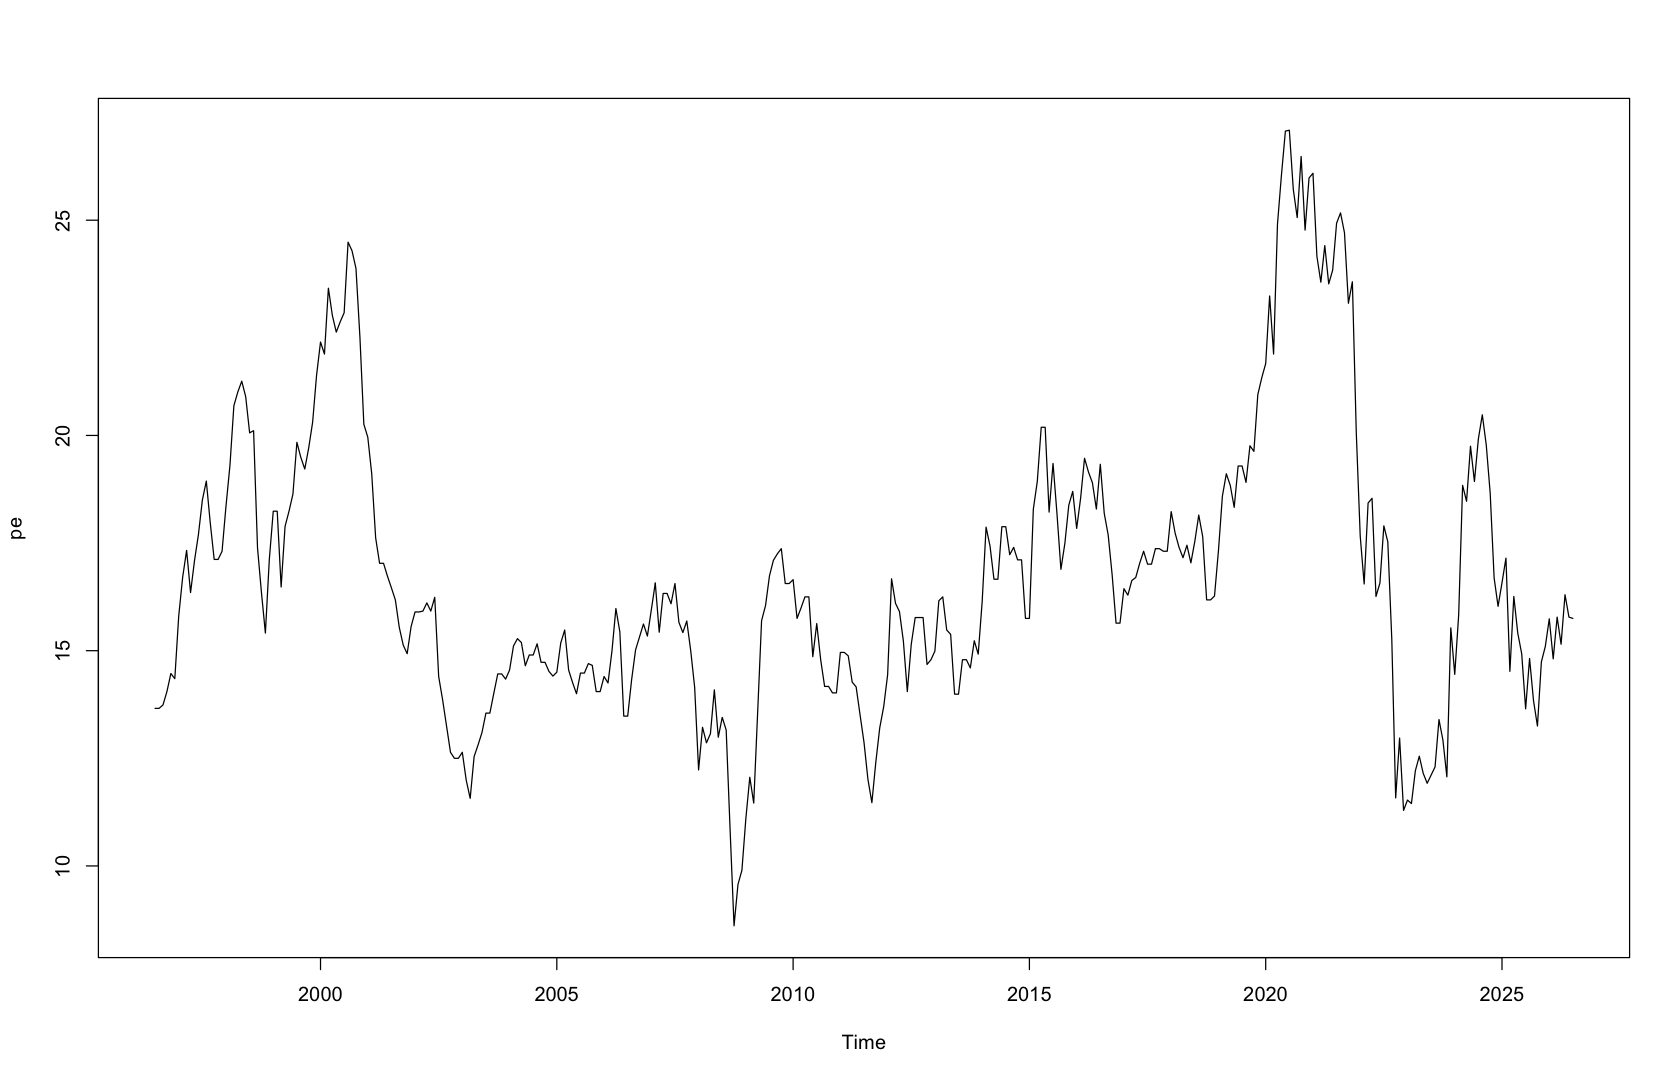

In [3]:
pe <- ts(pe$pe_ratio, 
                frequency = 12,
                start = c(1996, 7)
                )

plot(pe)

## Split into training and testing data (for forecasting), 95% and 5%, respectively

In [62]:
n <- length(pe)
n_train <- floor(0.95 * n) # 95% of the data are training data
#---------------
pe_train <- window(pe, end = time(pe)[n_train])
pe_test  <- window(pe, start = time(pe)[n_train + 1])

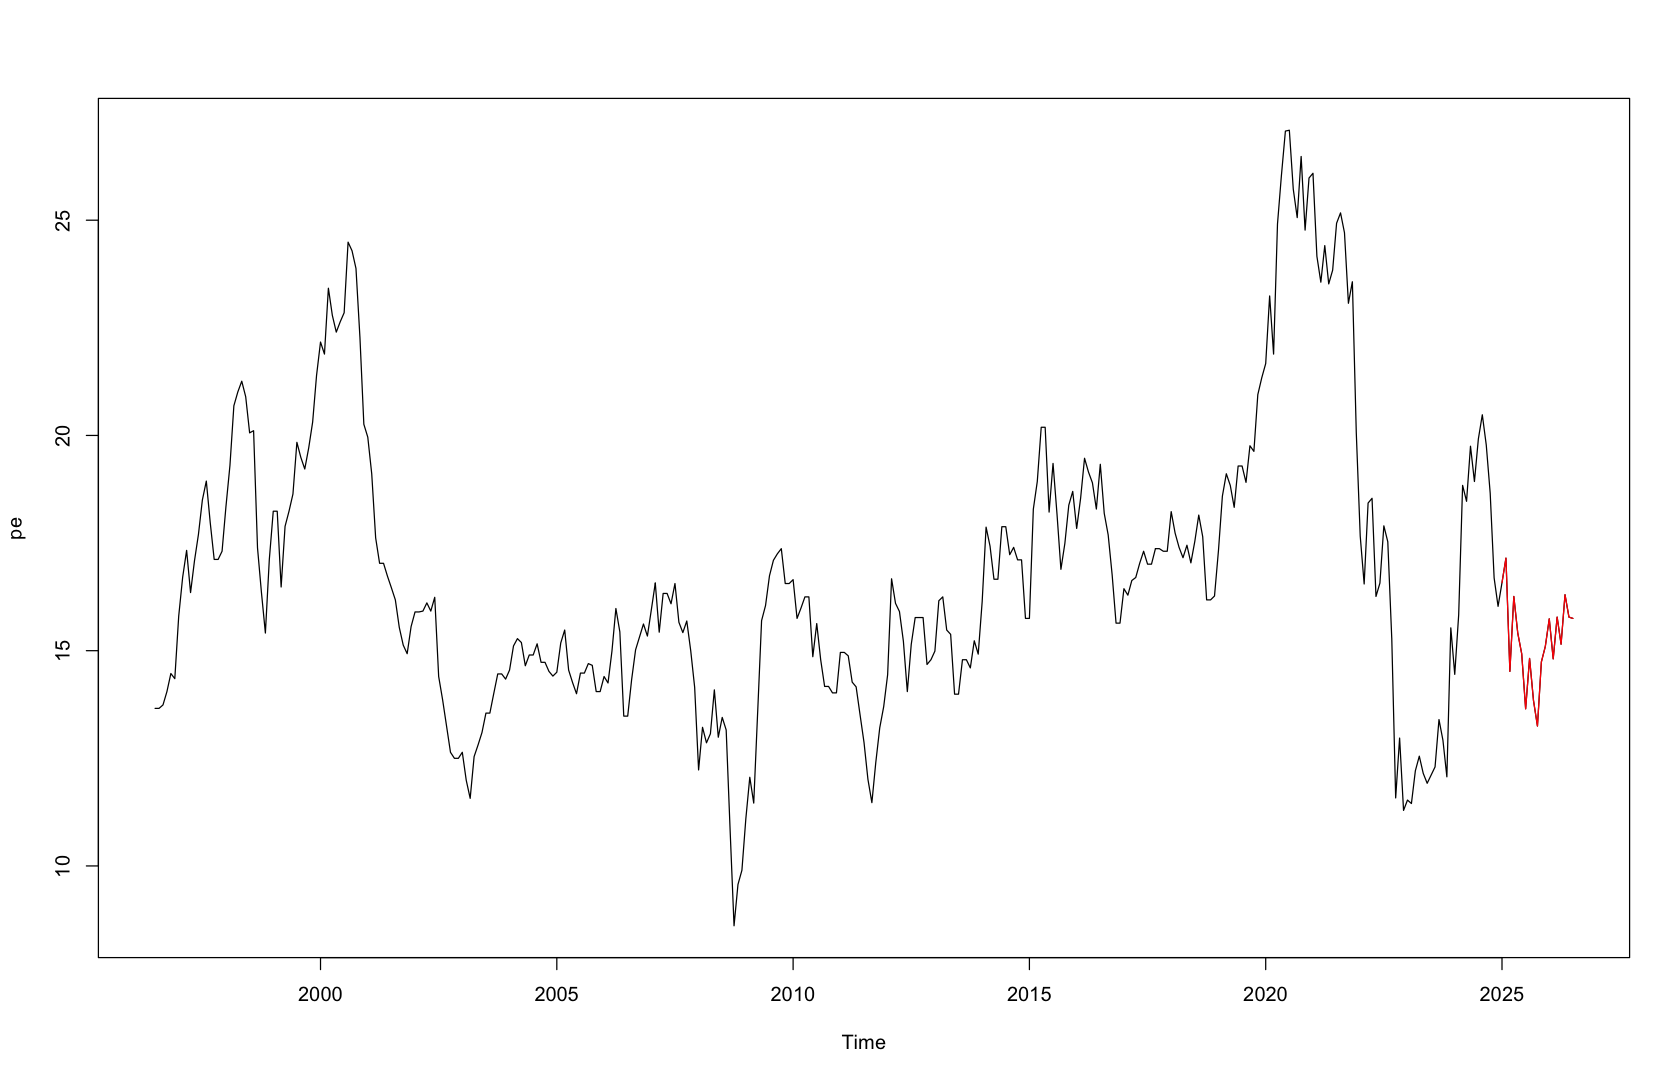

In [63]:
plot(pe)
lines(pe_test, col = 'red')

***

## Test for stationarity

In [64]:
library(tseries)

adf.test(pe_train)


	Augmented Dickey-Fuller Test

data:  pe_train
Dickey-Fuller = -3.0051, Lag order = 6, p-value = 0.1527
alternative hypothesis: stationary


## Test for seasonality

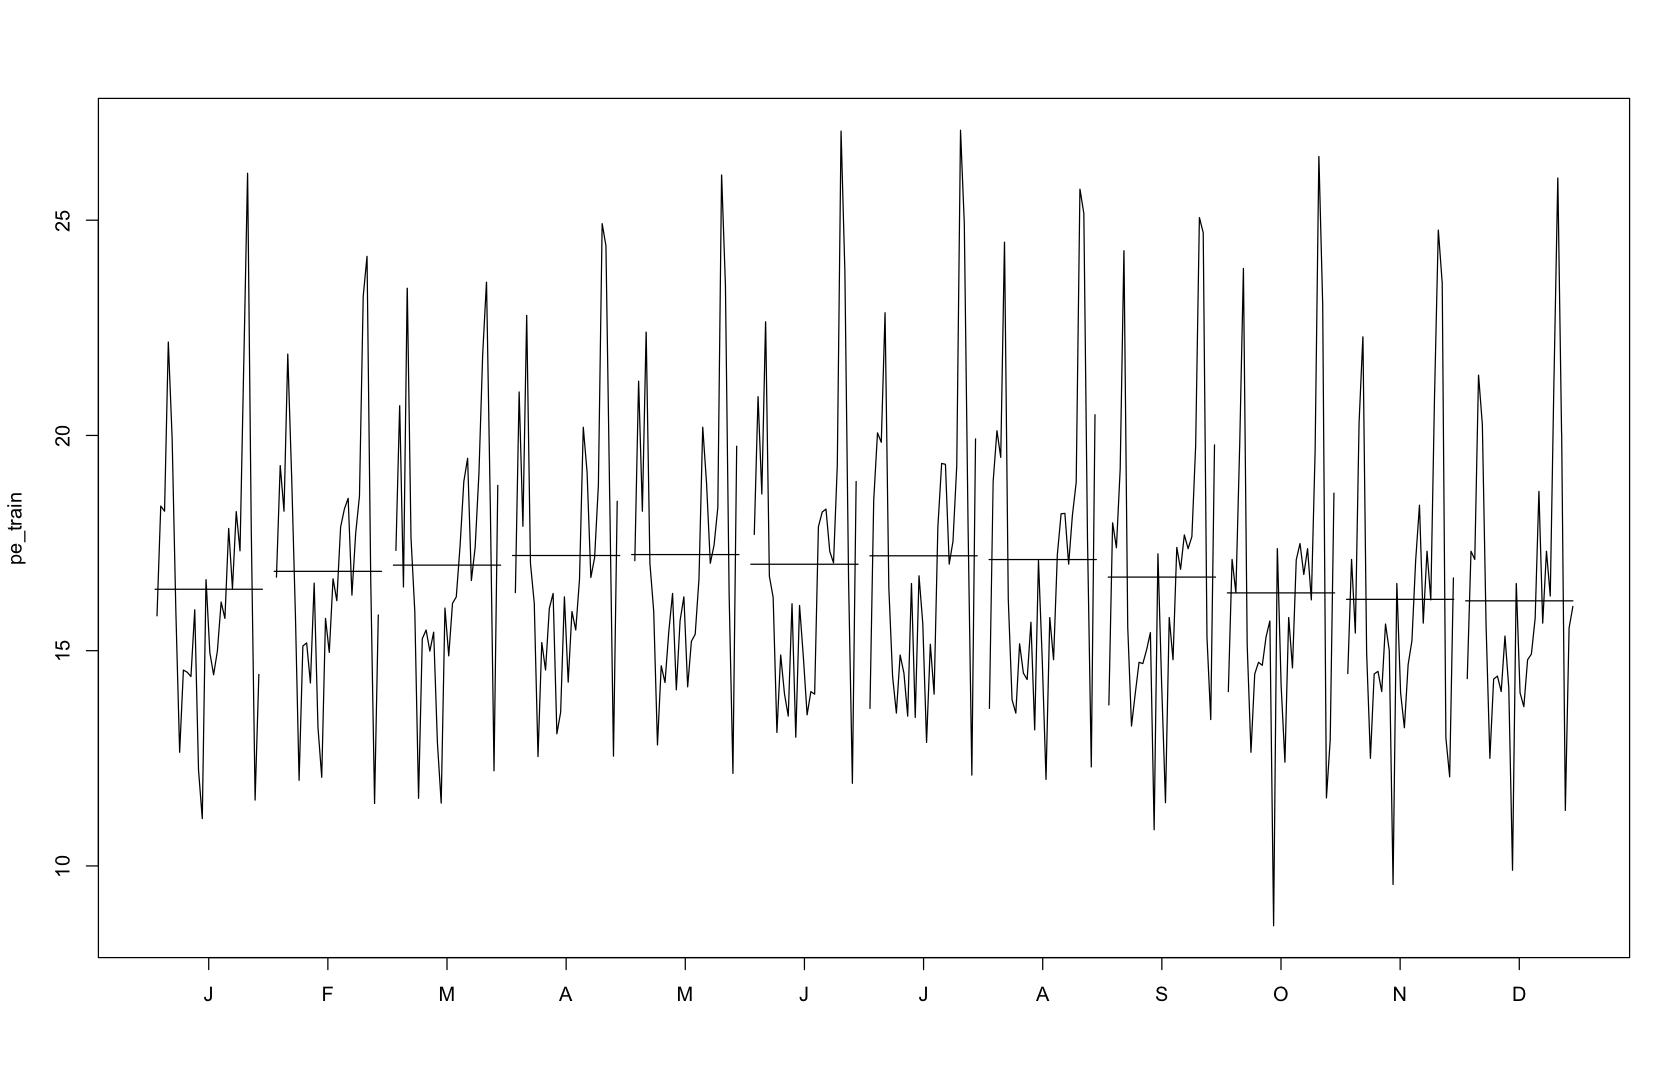

In [65]:
monthplot(pe_train)

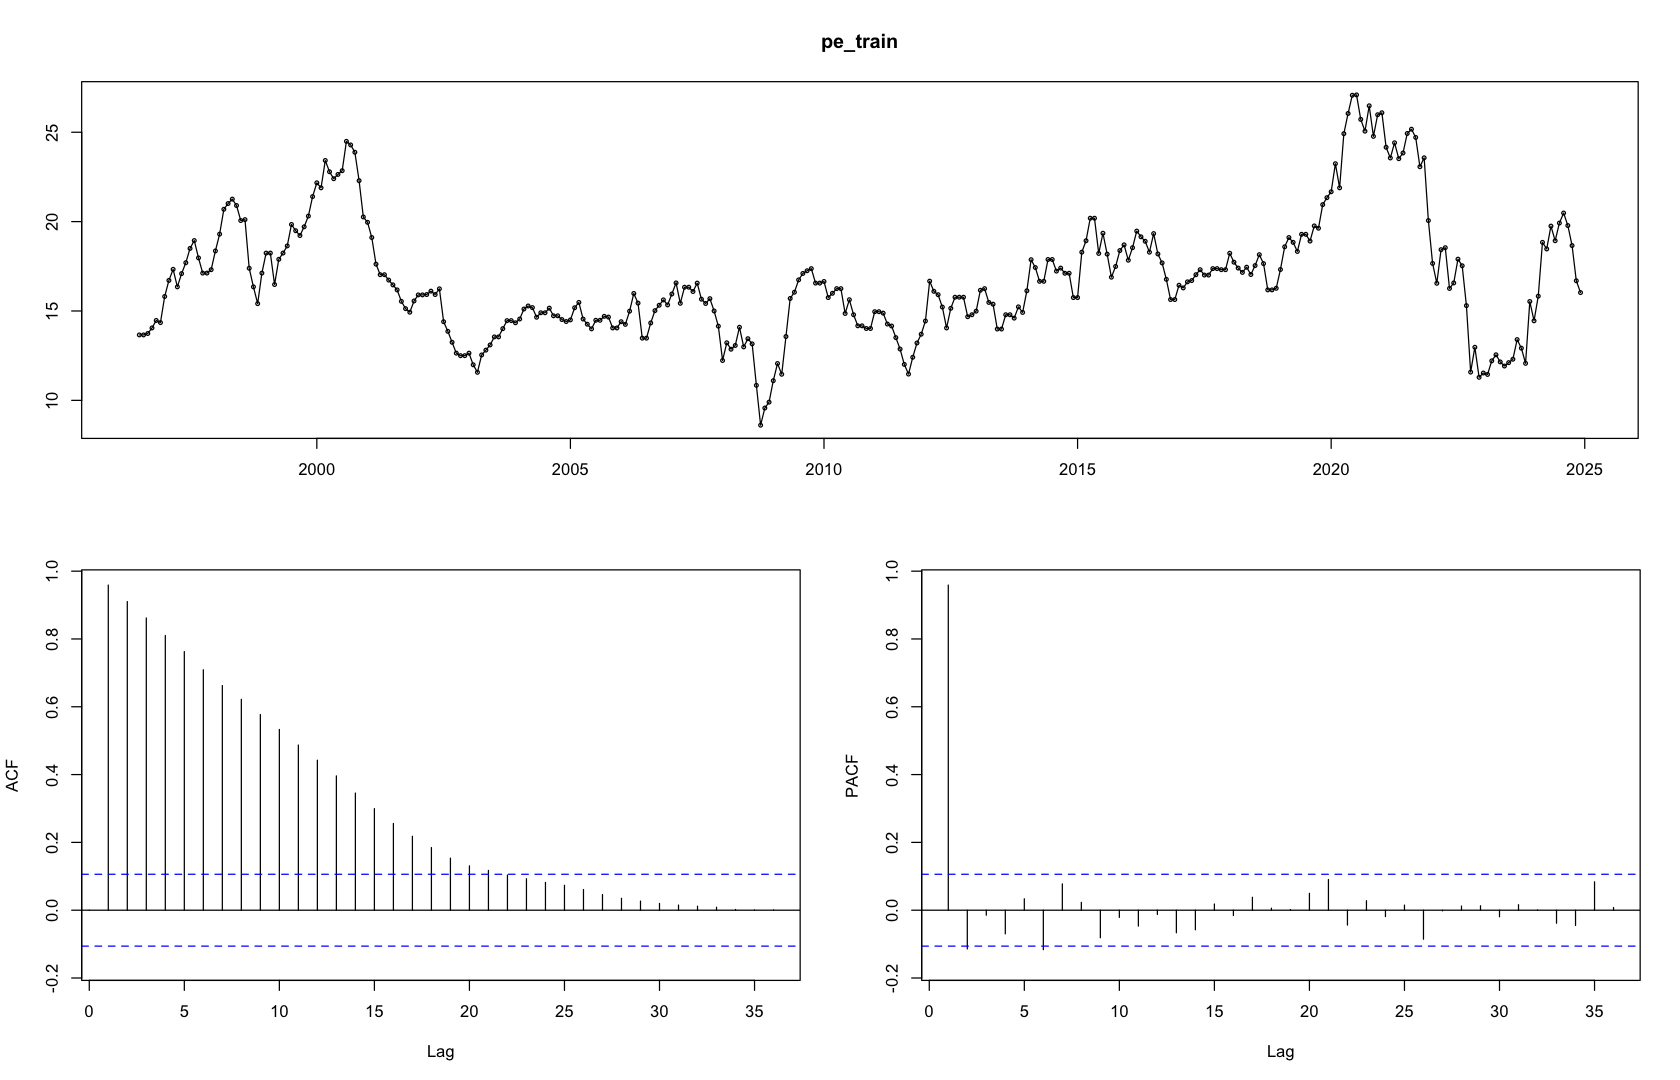

In [66]:
tsdisplay(pe_train)

In [67]:
arima100 <- Arima(pe_train, order = c(1, 0, 0))
arima200 <- Arima(pe_train, order = c(2, 0, 0))

print(arima100)
print(arima200)

Series: pe_train 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
         ar1     mean
      0.9588  16.5521
s.e.  0.0146   1.1552

sigma^2 = 0.8825:  log likelihood = -464.15
AIC=934.3   AICc=934.37   BIC=945.81


Series: pe_train 
ARIMA(2,0,0) with non-zero mean 

Coefficients:
         ar1      ar2     mean
      1.0721  -0.1178  16.5914
s.e.  0.0536   0.0536   1.0466

sigma^2 = 0.8727:  log likelihood = -461.76
AIC=931.51   AICc=931.63   BIC=946.85



	Ljung-Box test

data:  Residuals from ARIMA(1,0,0) with non-zero mean
Q* = 27.126, df = 23, p-value = 0.2506

Model df: 1.   Total lags used: 24



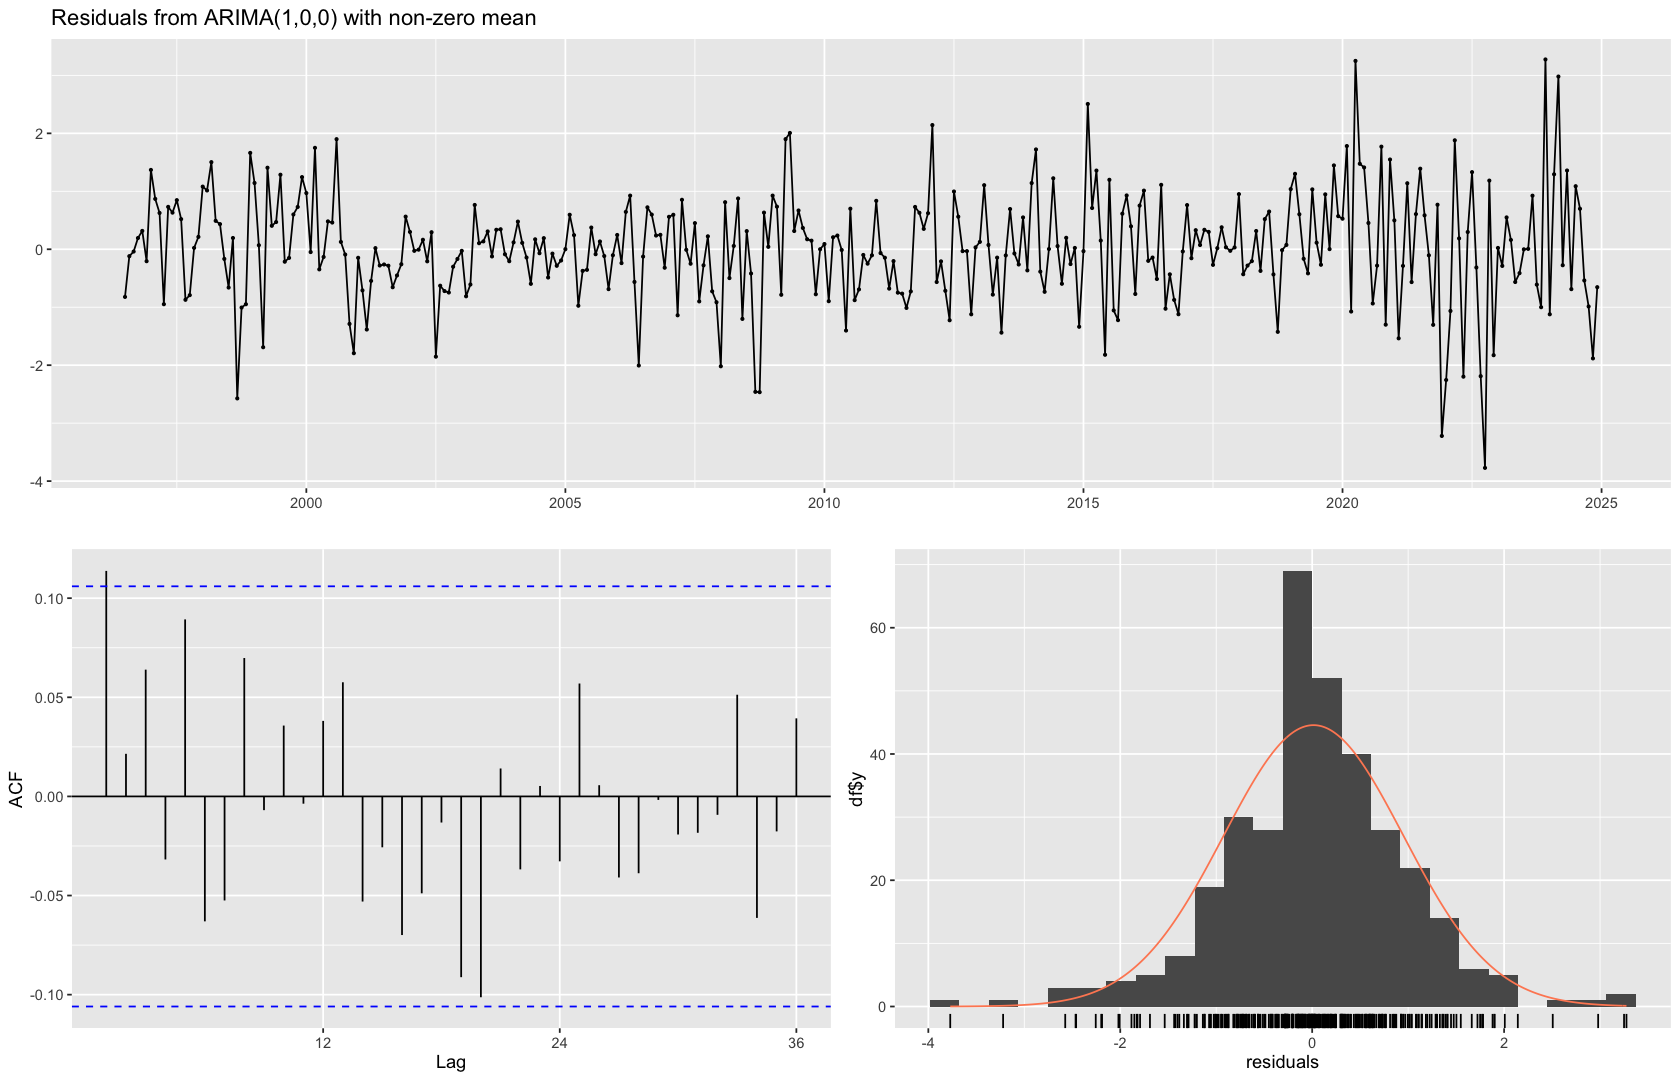

In [68]:
checkresiduals(arima100)


	Ljung-Box test

data:  Residuals from ARIMA(2,0,0) with non-zero mean
Q* = 23.936, df = 22, p-value = 0.3506

Model df: 2.   Total lags used: 24



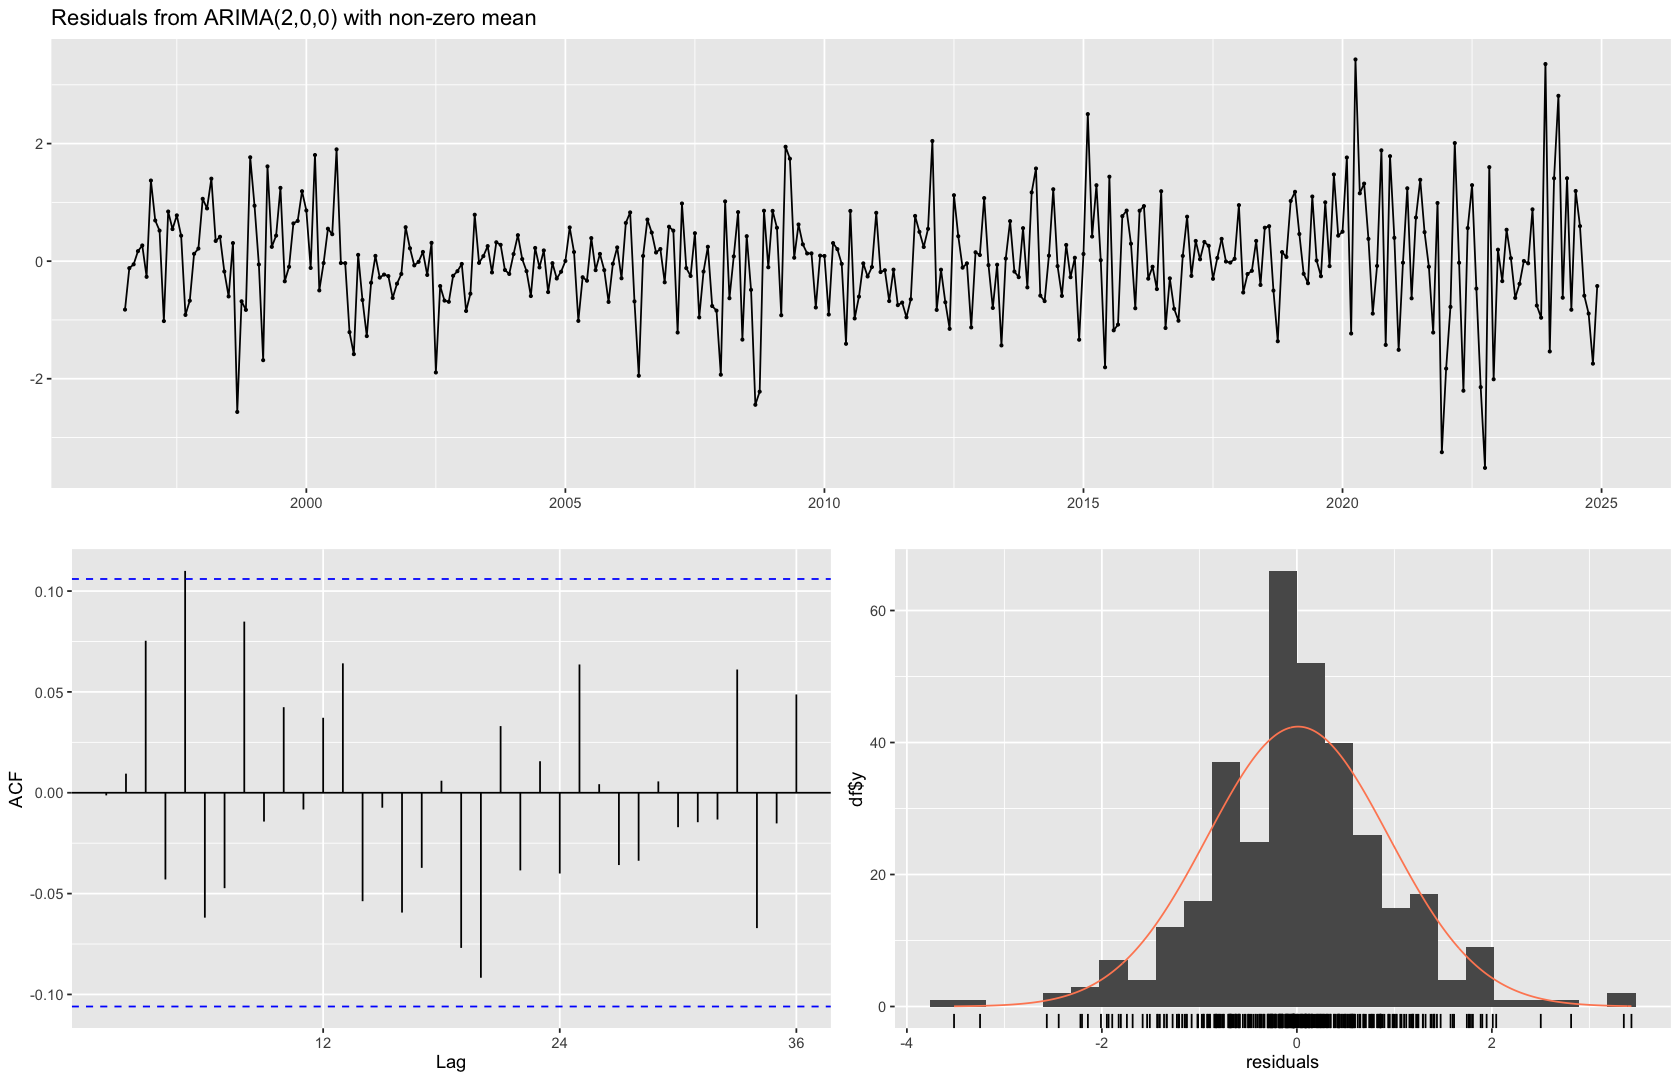

In [69]:
checkresiduals(arima200)

### The models are very similar and give good fits. The diviations for the data for both models are visible in the some extreme low and high values of the residuals. There reason can be the changing variance of the data. See in the top panel of the plot above: At the start of 2020 we observe a greater variance of the residuals. 

### AR(2) showed a more white-noise like ACF of the residuals, where only a single lag where ACF is significantly different from zero. In AR(1) there two significant ACF values significantly different from zero.  From these two models, AR(2) shown the lowest AIC and BIC scores. In summary, AR(2) showed better fit that AR(1) and should be preffered. 

***

# Forecasting

***

In [70]:
forecast_arima100 <- forecast(arima100, h = n - n_train) 
forecast_arima200 <- forecast(arima200, h = n - n_train) 

### AR(1) forecast

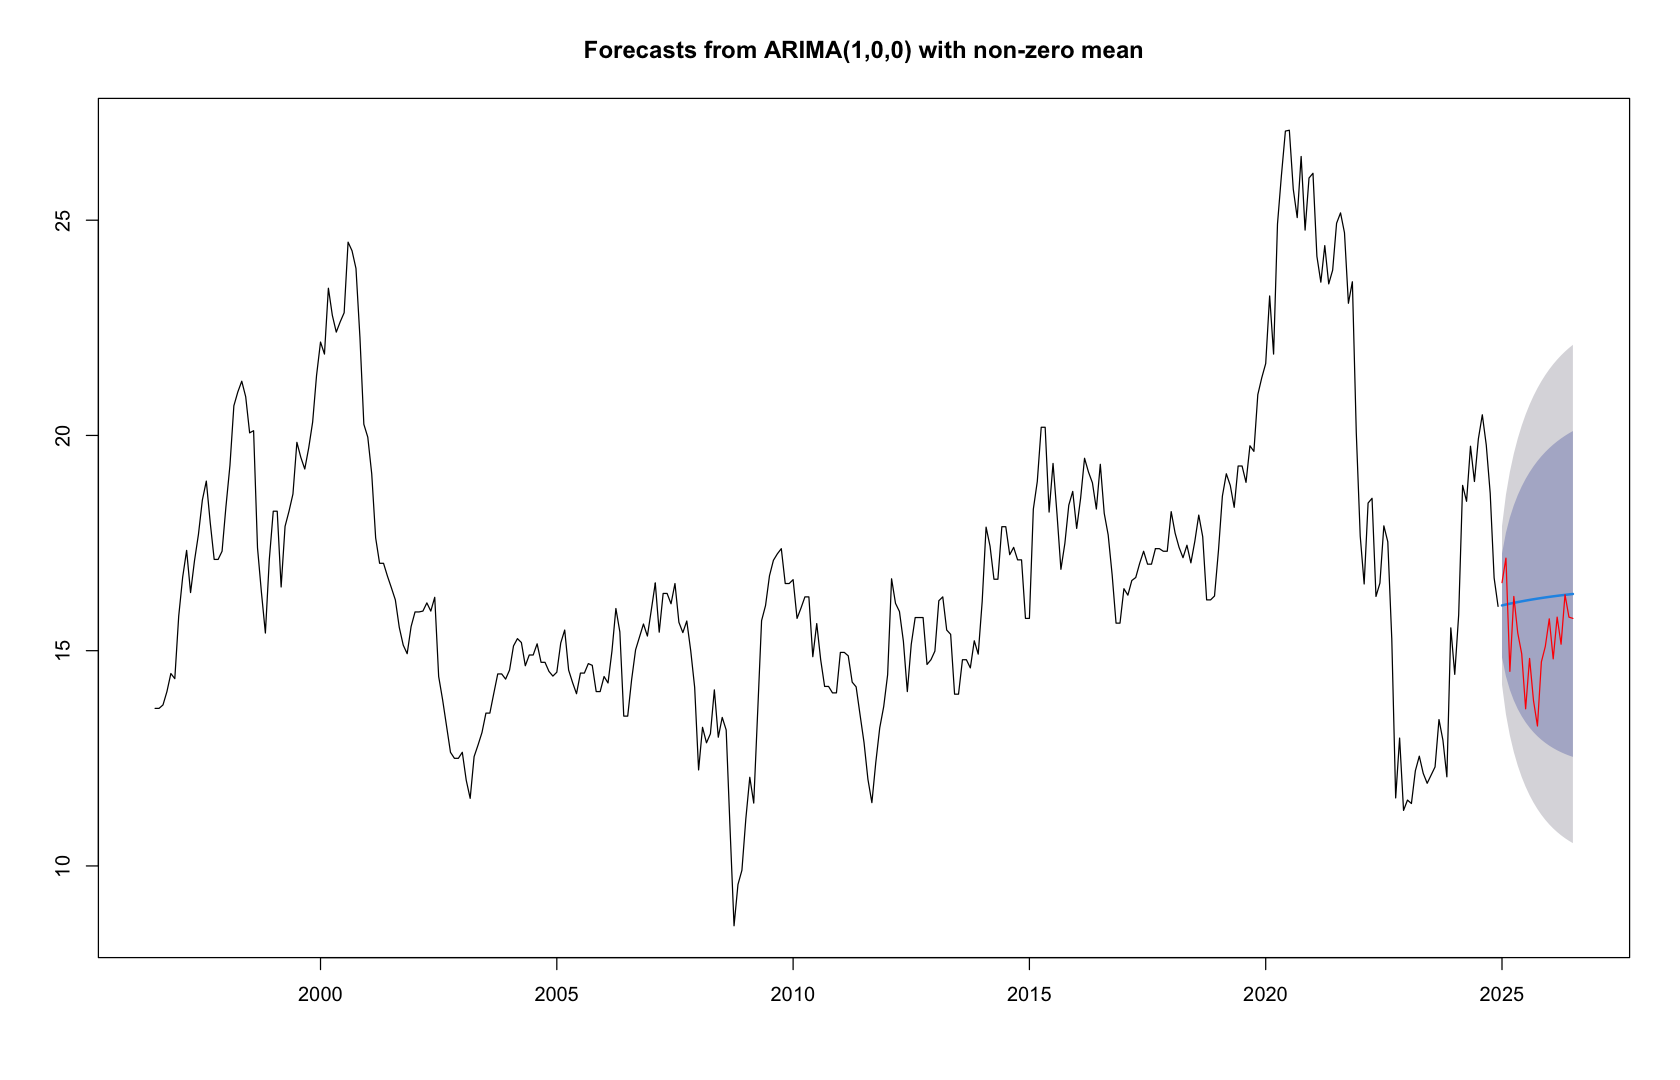

In [71]:
plot(forecast_arima100)
lines(pe_test, col = 'red')

### AR(2) forecast

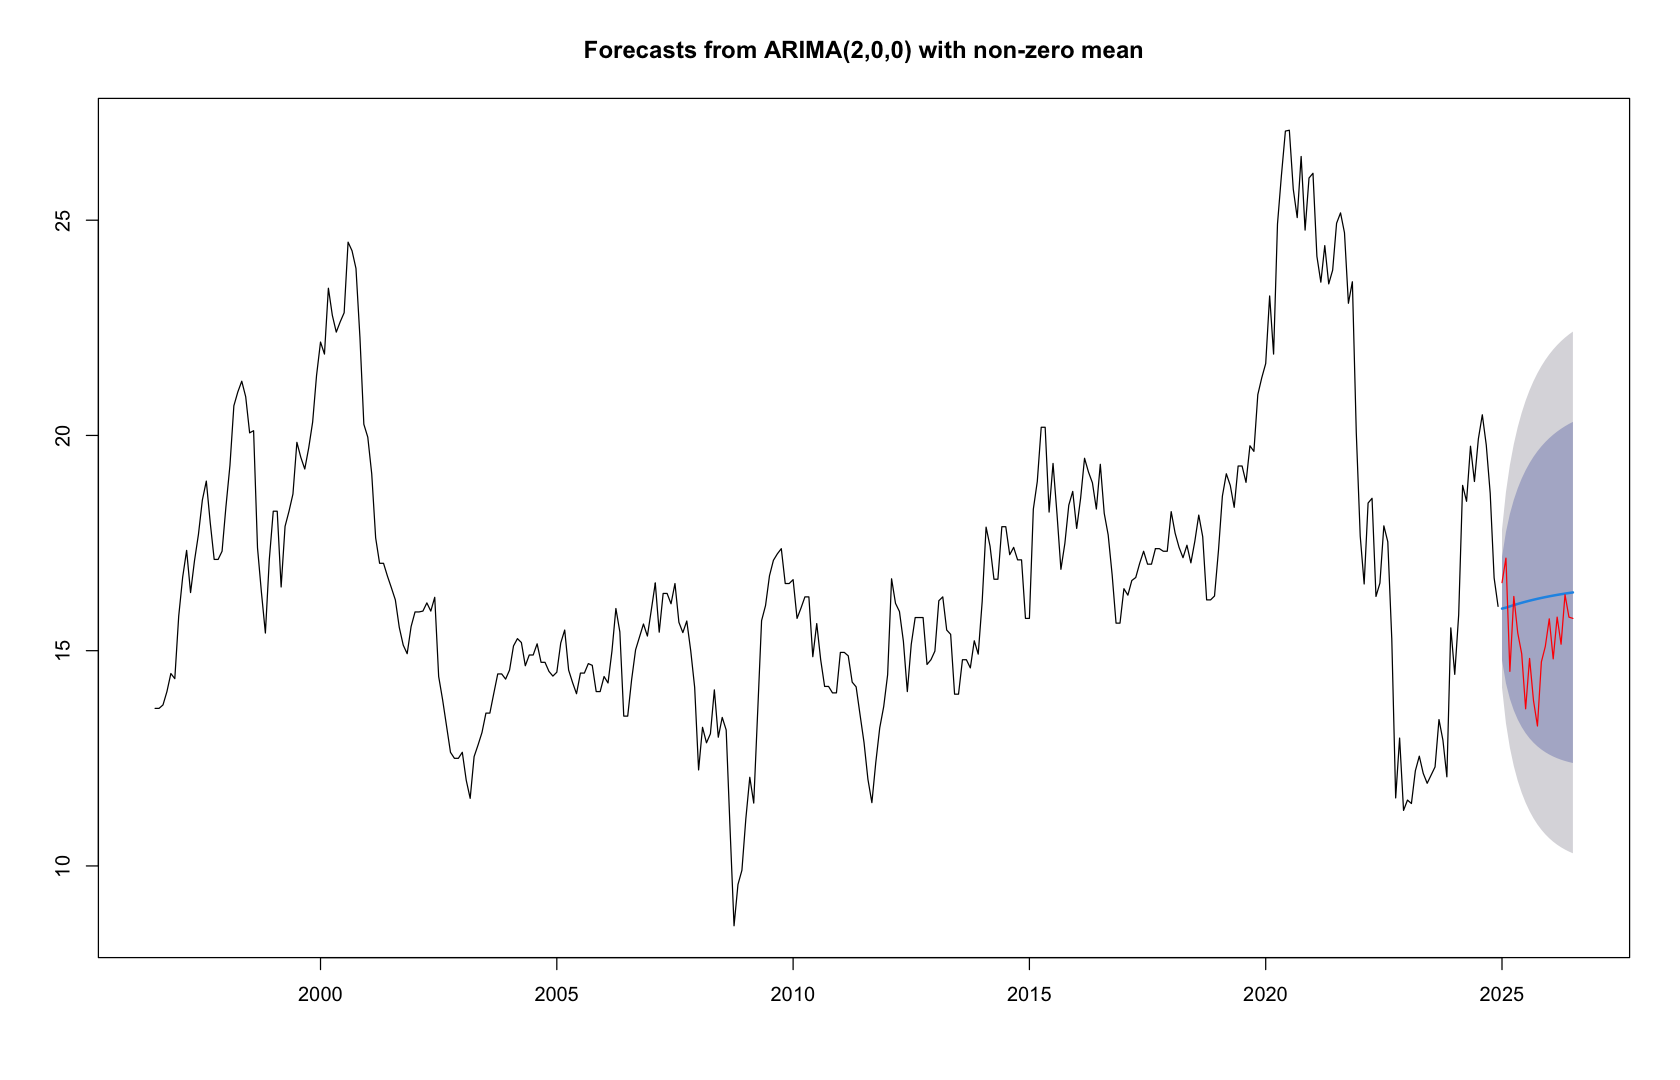

In [72]:
plot(forecast_arima200)
lines(pe_test, col = 'red')

### Benchmark AR(1) and AR(2) model against simple mean model

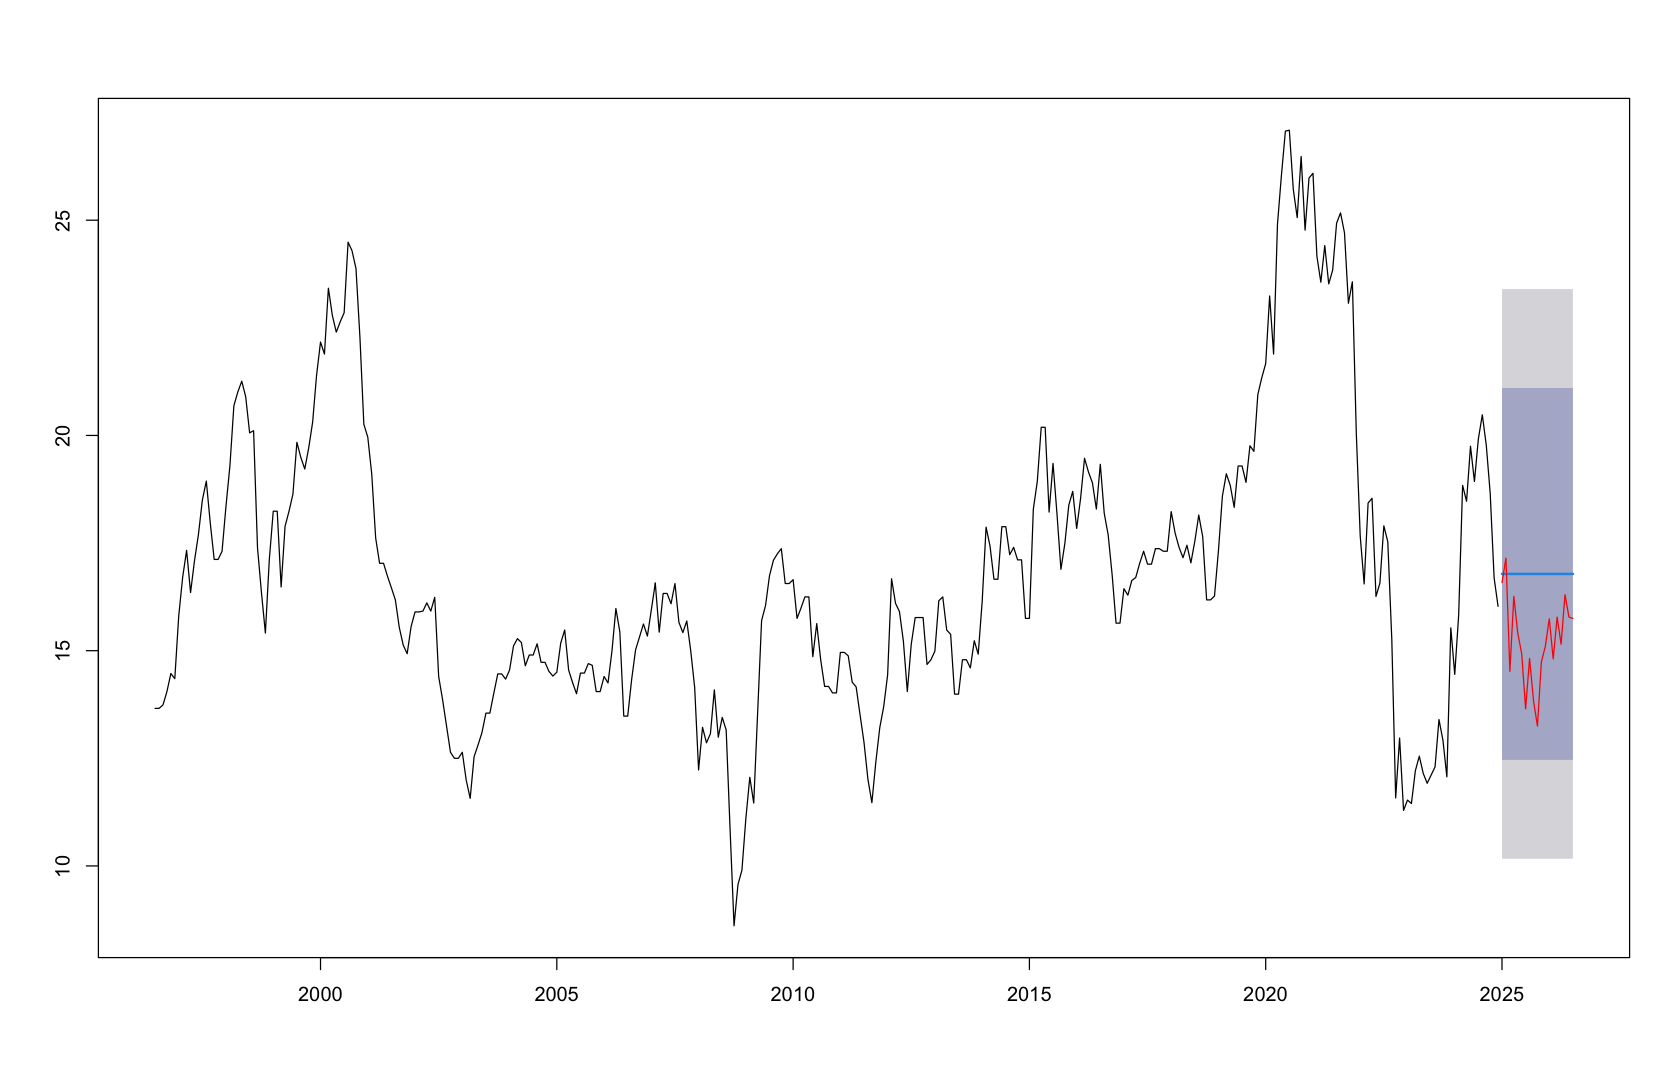

In [80]:
forecast_mean <- meanf(pe_train, h = n - n_train)

#---------------------------
plot(forecast_mean, main = "")
lines(pe_test, col = 'red')

***

## Compare forecasting accuracies of the three models

In [77]:
accuracy(forecast_arima100, pe_test)
accuracy(forecast_arima200, pe_test)
accuracy(forecast_mean, pe_test)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,0.0141209,0.9366456,0.6869888,-0.2356062,4.185433,0.2528426,0.1137517,NA
Test set,-0.9601982,1.3840445,1.1453105,-6.7569819,7.852615,0.4215256,0.3506947,1.32661


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,0.01237396,0.9300644,0.6813978,-0.2388648,4.157122,0.2507849,-0.00130415,NA
Test set,-0.94916693,1.3826696,1.1547979,-6.6860741,7.904555,0.4250174,0.35666531,1.3238


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-1.105397e-15,3.353786,2.555663,-3.836133,15.53130,0.9405986,0.9589196,NA
Test set,-1.543275e+00,1.830787,1.581878,-10.596627,10.82172,0.5822018,0.3448860,1.754182


***

# Summary:
- AR(1) and AR(2) models outperform simple mean models, while AR(1) and AR(2) are very close in their accuracy. 
- The differences between AR(1) and AR(2) are tiny—for example, RMSE is 1.3840 vs 1.3827. Because the two models are very similar, I suggest choosing the simplest model AR(1). 
- A high autocorrelation (~0.35) of residuals in the test set for both models, which indicates how the two models failed to explain patterns in the test data. Adjustment of the models is likely needed to increase performance.
- PE-ratio of Denmark, starting at 1997, is well-described by the autoregressive AR(1) process (essentially a random-walk process).

***